# Environment Setup & Dependencies

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from catboost import CatBoostRegressor

from features import build_company_freq, preprocess_dataframe

sns.set_theme(style="darkgrid")

# Reading the Data

In [2]:
df = pd.read_csv("data/Salary_Dataset_with_Extra_Features.csv").fillna("")
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [3]:
df["Salary_LPA"] = df["Salary"] / 1e5      # annual salary in Lakhs (LPA)
print("Shape:", df.shape)
df["Salary_LPA"].describe()

Shape: (22770, 9)


count    22770.000000
mean         6.953872
std          8.843990
min          0.021120
25%          3.000000
50%          5.000000
75%          9.000000
max        900.000000
Name: Salary_LPA, dtype: float64

Some salaries are unrealistic (for example 0.02 LPA or 900 LPA), so we keep only salaries between 0.5 and 100 LPA.

In [4]:
MIN_LPA, MAX_LPA = 0.5, 100

before = len(df)
df = df[df["Salary_LPA"].between(MIN_LPA, MAX_LPA)].reset_index(drop=True)
print(f"Removed {before - len(df)} unrealistic rows, {len(df)} rows remaining")

Removed 83 unrealistic rows, 22687 rows remaining


# Feature Engineering

The feature logic lives in `features.py` so the Streamlit app can reuse exactly the same code. It creates:

- **Seniority** and **Job_Level** from the job title (Intern, Junior, Senior, SDE I / II / III ...)
- **Domain_Group** (Mobile, Frontend, Backend, QA ...)
- **Company_Clean** and **Company_Tier** (Top Tech, Startup, Service IT, ...)
- **Company_Freq** and location flags (major hub, Bangalore)

In [5]:
df = preprocess_dataframe(df)

df[["Company Name", "Company_Tier", "Job Title", "Domain_Group",
    "Seniority", "Job_Level", "Salary_LPA"]].head(10)

,Company Name,Company_Tier,Job Title,Domain_Group,Seniority,Job_Level,Salary_LPA
0,Sasken,Other,Android Developer,Mobile,Mid_Level,0,4.00
1,Advanced Millennium Technologies,Other,Android Developer,Mobile,Mid_Level,0,4.00
2,Unacademy,Product_Startup,Android Developer,Mobile,Mid_Level,0,10.00
3,SnapBizz Cloudtech,Other,Android Developer,Mobile,Mid_Level,0,3.00
4,Appoids Tech Solutions,Other,Android Developer,Mobile,Mid_Level,0,6.00
5,Freelancer,Unknown_Junk,Android Developer,Mobile,Mid_Level,0,1.00
6,SQUARE N CUBE,Other,Android Developer,Mobile,Mid_Level,0,1.92
7,Samsung R&D Institute India - Bangalore,Top_Tech,Android Developer,Mobile,Mid_Level,0,4.00
8,DXMinds Technologies,Other,Android Developer,Mobile,Mid_Level,0,3.00
9,Endeavour Software Technologies,Other,Android Developer,Mobile,Mid_Level,0,6.00


# Train-Test Split

In [6]:
num_feats = ["Rating", "Salaries Reported", "Is_Tier1_Company", "Is_Major_Hub",
             "Is_Bangalore", "Is_Junk_Company", "Company_Freq", "Job_Level"]
low_cat = ["Company_Tier", "Domain_Group", "Seniority", "Location",
           "Employment Status", "Job Roles"]
high_cat = ["Company_Clean", "Job Title"]          # thousands of unique values
cat_feats = low_cat + high_cat

X = df[num_feats + cat_feats].copy()
X[cat_feats] = X[cat_feats].astype(str)
y = np.log1p(df["Salary_LPA"])                      # log scale: salaries are right-skewed

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (18149, 16) | Test: (4538, 16)


# Train the Model

**Baseline: Random Forest** (one-hot encodes the small categorical columns only)

In [8]:
preprocessor = ColumnTransformer([
    ("num", "passthrough", num_feats),
    ("cat", OneHotEncoder(handle_unknown="ignore"), low_cat),
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, max_depth=14, n_jobs=-1, random_state=42)),
])

In [9]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['Rating','Salaries Reported','Is_Tier1_Company',...,'Job Roles', 'Company_Clean','Job Title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through.

**Final model: CatBoost** (handles company names and job titles natively, which is where most of the signal is)

In [10]:
cat_model = CatBoostRegressor(iterations=800, learning_rate=0.05, depth=6, l2_leaf_reg=3,
                              cat_features=cat_feats, random_seed=42, verbose=0)

In [11]:
cat_model.fit(X_train, y_train)

CatBoostRegressor(cat_features=['Company_Tier', 'Domain_Group', 'Seniority', 'Location', 'Employment Status', 'Job Roles', 'Company_Clean', 'Job Title'], depth=6, iterations=800, l2_leaf_reg=3, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0)

# Data Visualization

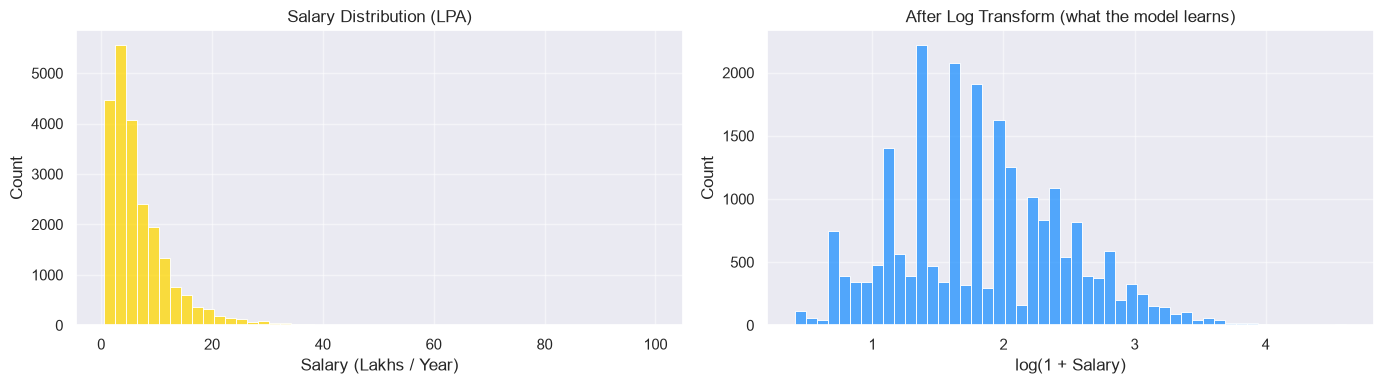

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["Salary_LPA"], bins=50, color="gold", ax=axes[0])
axes[0].set_title("Salary Distribution (LPA)")
axes[0].set_xlabel("Salary (Lakhs / Year)")

sns.histplot(np.log1p(df["Salary_LPA"]), bins=50, color="dodgerblue", ax=axes[1])
axes[1].set_title("After Log Transform (what the model learns)")
axes[1].set_xlabel("log(1 + Salary)")

plt.tight_layout()
plt.show()

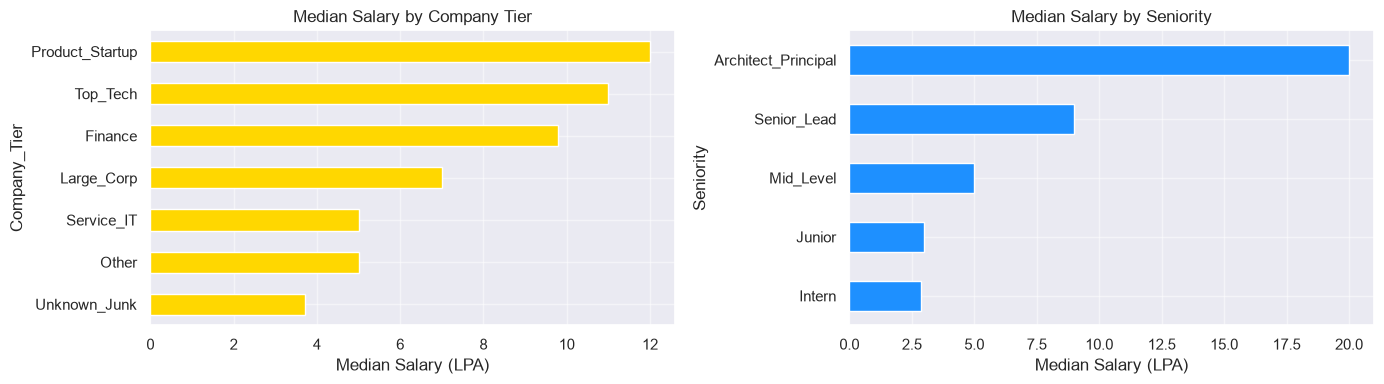

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby("Company_Tier")["Salary_LPA"].median().sort_values().plot.barh(ax=axes[0], color="gold")
axes[0].set_title("Median Salary by Company Tier")
axes[0].set_xlabel("Median Salary (LPA)")

df.groupby("Seniority")["Salary_LPA"].median().sort_values().plot.barh(ax=axes[1], color="dodgerblue")
axes[1].set_title("Median Salary by Seniority")
axes[1].set_xlabel("Median Salary (LPA)")

plt.tight_layout()
plt.show()

In [14]:
y_pred = cat_model.predict(X_test)
actual_lpa = np.expm1(y_test)
pred_lpa = np.expm1(y_pred)

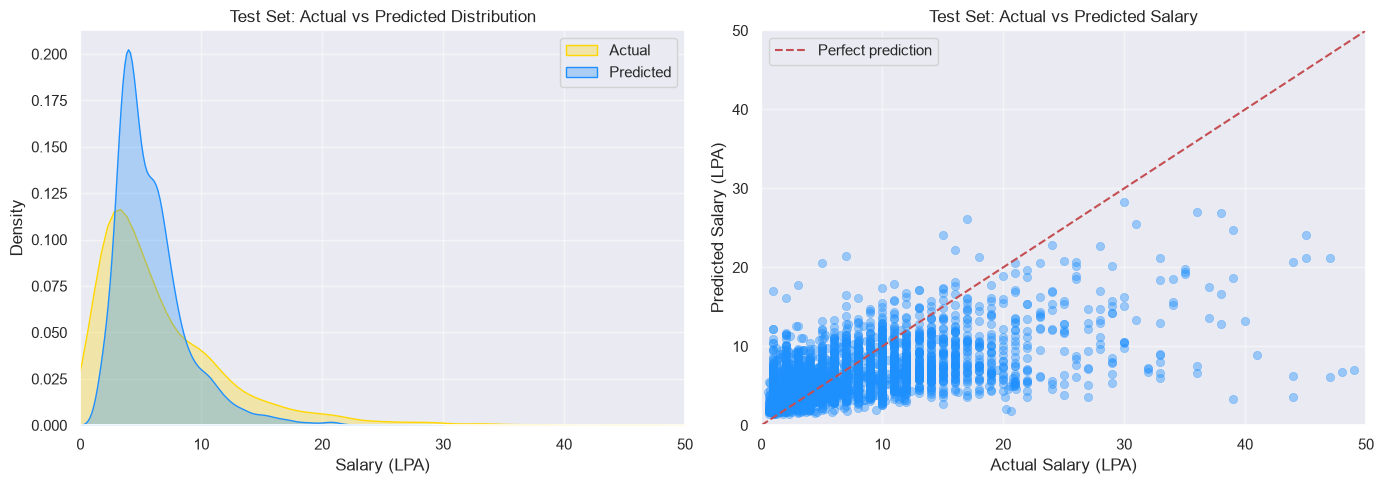

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(actual_lpa, ax=axes[0], label="Actual", color="gold", fill=True, alpha=0.3)
sns.kdeplot(pred_lpa, ax=axes[0], label="Predicted", color="dodgerblue", fill=True, alpha=0.3)
axes[0].set_xlim(0, 50)
axes[0].set_title("Test Set: Actual vs Predicted Distribution")
axes[0].set_xlabel("Salary (LPA)")
axes[0].legend()

sns.scatterplot(x=actual_lpa, y=pred_lpa, ax=axes[1], color="dodgerblue", alpha=0.4, edgecolor=None)
axes[1].plot([0, 50], [0, 50], "r--", label="Perfect prediction")
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, 50)
axes[1].set_title("Test Set: Actual vs Predicted Salary")
axes[1].set_xlabel("Actual Salary (LPA)")
axes[1].set_ylabel("Predicted Salary (LPA)")
axes[1].legend()

plt.tight_layout()
plt.show()

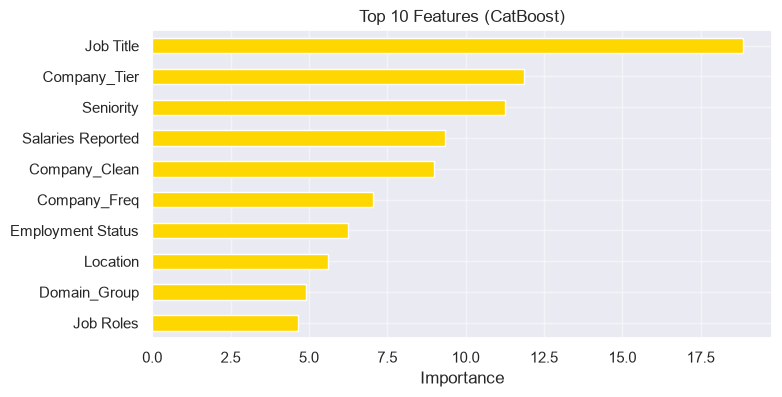

In [16]:
importance = pd.Series(cat_model.get_feature_importance(), index=X_train.columns).sort_values()

importance.tail(10).plot.barh(figsize=(8, 4), color="gold")
plt.title("Top 10 Features (CatBoost)")
plt.xlabel("Importance")
plt.show()

# Evaluation

Salary is hard to predict exactly, so besides R² we report percentage errors:

- **R² (log)**: share of salary variation explained (higher is better)
- **Median APE %**: typical percentage error of a prediction (lower is better)
- **Within ±25%**: share of predictions within 25% of the real salary
- **MAE (LPA)**: average error in Lakhs

In [17]:
def evaluate(y_true_log, y_pred_log, name="Model"):
    y_true, y_pred = np.expm1(np.asarray(y_true_log)), np.expm1(np.asarray(y_pred_log))
    ape = np.abs(y_pred - y_true) / y_true
    return {
        "Model": name,
        "R² (log)": r2_score(y_true_log, y_pred_log),
        "R² (LPA)": r2_score(y_true, y_pred),
        "Median APE %": np.median(ape) * 100,
        "Within ±25%": (ape <= 0.25).mean() * 100,
        "MAE (LPA)": mean_absolute_error(y_true, y_pred),
    }

In [18]:
results = pd.DataFrame([
    evaluate(y_test, rf_model.predict(X_test), "Random Forest (baseline)"),
    evaluate(y_test, cat_model.predict(X_test), "CatBoost (final)"),
]).set_index("Model").round(3)

results

,R² (log),R² (LPA),Median APE %,Within ±25%,MAE (LPA)
Model,,,,,
Random Forest (baseline),0.307,0.247,40.373,31.996,3.304
CatBoost (final),0.356,0.275,37.809,33.715,3.189


Users may type a company the model has never seen, so we check both cases:

In [19]:
seen = X_test["Company_Clean"].isin(set(X_train["Company_Clean"])).values

pd.DataFrame([
    {**evaluate(y_test.values[seen], y_pred[seen], "Company seen in training"), "Rows": seen.sum()},
    {**evaluate(y_test.values[~seen], y_pred[~seen], "Company NOT in training"), "Rows": (~seen).sum()},
]).set_index("Model").round(3)

,R² (log),R² (LPA),Median APE %,Within ±25%,MAE (LPA),Rows
Model,,,,,,
Company seen in training,0.382,0.299,35.707,36.445,3.395,2807
Company NOT in training,0.229,0.147,43.009,29.289,2.854,1731


Typical error range: the middle 80% of prediction errors, shown for a 10 LPA prediction.

In [20]:
residuals = y_test.values - y_pred
intervals = {
    "seen": np.quantile(residuals[seen], [0.10, 0.90]),
    "unseen": np.quantile(residuals[~seen], [0.10, 0.90]),
}

for group, (low, high) in intervals.items():
    lo_lpa = np.expm1(np.log1p(10) + low)
    hi_lpa = np.expm1(np.log1p(10) + high)
    print(f"{group:>6} company: a 10 LPA prediction is usually between {lo_lpa:.1f} and {hi_lpa:.1f} LPA")

  seen company: a 10 LPA prediction is usually between 4.7 and 19.5 LPA
unseen company: a 10 LPA prediction is usually between 4.5 and 19.8 LPA


# Saving the Model

In [21]:
artifact = {
    "model": cat_model,
    "num_feats": num_feats,
    "cat_feats": cat_feats,
    "feature_order": list(X_train.columns),
    "company_freq": build_company_freq(df),
    "known_companies": set(df["Company_Clean"]),
    "intervals_log": {k: v.tolist() for k, v in intervals.items()},
    "test_metrics": results.loc["CatBoost (final)"].to_dict(),
}

os.makedirs("models", exist_ok=True)
joblib.dump(artifact, "models/salary_catboost_artifact.joblib")
print("Saved CatBoost model to 'models/salary_catboost_artifact.joblib'")

Saved CatBoost model to 'models/salary_catboost_artifact.joblib'
